# Exercícios — Testes de Hipótese

**Tema:** Estatística › Testes de Hipótese

Um teste de hipótese não descobre a verdade — ele controla a taxa de um tipo
específico de erro. Os exercícios abaixo constroem essa intuição por
**simulação**, que é a única forma de ver os erros acontecendo.

1. **Enunciado** → 2. **Célula de resposta** → 3. **Gabarito comentado**.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(31415)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"


def painel(titulo, **metricas):
    print(titulo)
    print("-" * max(len(titulo), 48))
    for nome, valor in metricas.items():
        rotulo = nome.replace("_", " ")
        print(f"{rotulo:<34s} {valor:>12.5f}" if isinstance(valor, (int, float, np.floating))
              else f"{rotulo:<34s} {valor:>12}")
    print()


print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — O que o p-valor é e o que ele não é

Marque **verdadeiro ou falso** para cada afirmação e justifique em uma linha.
Depois, verifique a de número (e) por simulação.

| # | Afirmação |
|---|---|
| a | O p-valor é a probabilidade de $H_0$ ser verdadeira |
| b | $p = 0{,}04$ significa 4% de chance de o resultado ser um falso positivo |
| c | $p > 0{,}05$ significa que não há efeito |
| d | Um p-valor menor indica um efeito maior |
| e | Sob $H_0$, o p-valor é uniforme em $[0,1]$ |
| f | $p = 0{,}049$ e $p = 0{,}051$ são conclusões qualitativamente diferentes |

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
gabarito_1 = {
    "a": "FALSO — p = P(dados tão extremos | H0), não P(H0 | dados). São condicionais invertidas.",
    "b": "FALSO — a taxa de falsos positivos entre descobertas depende da prevalência de efeitos reais (Ex. 6).",
    "c": "FALSO — ausência de evidência ≠ evidência de ausência. Pode ser só falta de poder.",
    "d": "FALSO — p depende do efeito E de n. Efeito minúsculo com n=1e6 dá p microscópico.",
    "e": "VERDADEIRO — e é isso que faz o controle de alfa funcionar. Verificado abaixo.",
    "f": "FALSO — a diferença entre eles é ruído. O limiar 0,05 é convenção, não descontinuidade da natureza.",
}
for k, v in gabarito_1.items():
    print(f"({k}) {v}")

(a) FALSO — p = P(dados tão extremos | H0), não P(H0 | dados). São condicionais invertidas.
(b) FALSO — a taxa de falsos positivos entre descobertas depende da prevalência de efeitos reais (Ex. 6).
(c) FALSO — ausência de evidência ≠ evidência de ausência. Pode ser só falta de poder.
(d) FALSO — p depende do efeito E de n. Efeito minúsculo com n=1e6 dá p microscópico.
(e) VERDADEIRO — e é isso que faz o controle de alfa funcionar. Verificado abaixo.
(f) FALSO — a diferença entre eles é ruído. O limiar 0,05 é convenção, não descontinuidade da natureza.


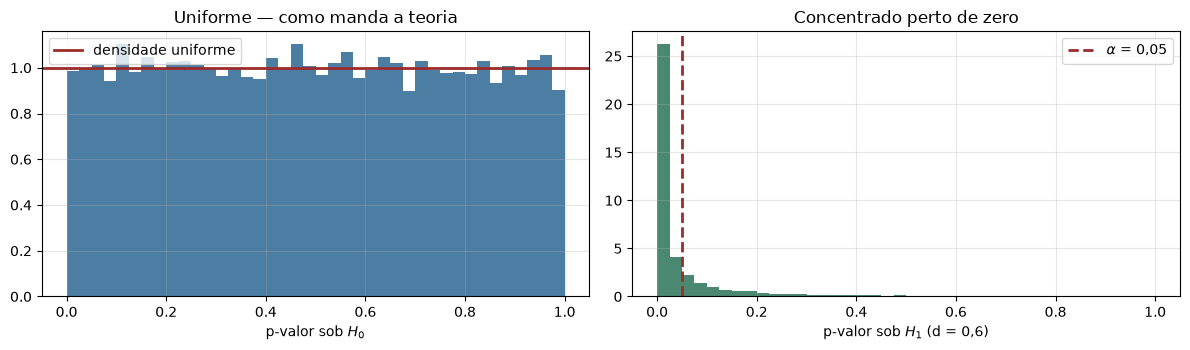

P(p < 0,05) sob H0: 0.0495  ← é o próprio alfa
P(p < 0,05) sob H1: 0.7580  ← é o PODER


In [4]:
# (e) sob H0, o p-valor é uniforme
p_sob_h0 = np.array([stats.ttest_ind(rng.normal(0, 1, 40), rng.normal(0, 1, 40)).pvalue
                     for _ in range(20_000)])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(p_sob_h0, bins=40, color=AZUL, alpha=0.8, density=True)
axes[0].axhline(1.0, color=VERMELHO, lw=2, label="densidade uniforme")
axes[0].set_xlabel("p-valor sob $H_0$"); axes[0].set_title("Uniforme — como manda a teoria")
axes[0].legend()

p_sob_h1 = np.array([stats.ttest_ind(rng.normal(0, 1, 40), rng.normal(0.6, 1, 40)).pvalue
                     for _ in range(20_000)])
axes[1].hist(p_sob_h1, bins=40, color=VERDE, alpha=0.8, density=True)
axes[1].axvline(0.05, color=VERMELHO, lw=2, ls="--", label=r"$\alpha$ = 0,05")
axes[1].set_xlabel("p-valor sob $H_1$ (d = 0,6)")
axes[1].set_title("Concentrado perto de zero"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"P(p < 0,05) sob H0: {(p_sob_h0 < 0.05).mean():.4f}  ← é o próprio alfa")
print(f"P(p < 0,05) sob H1: {(p_sob_h1 < 0.05).mean():.4f}  ← é o PODER")

**A afirmação (e) é o coração do método.** Se o p-valor é uniforme sob $H_0$,
então $P(p < 0{,}05 \mid H_0) = 0{,}05$ **exatamente** — o teste entrega o
controle de erro tipo I que promete. Todo o aparato existe para preservar essa
uniformidade; espiar dados, escolher teste depois de ver o resultado ou testar
vários segmentos **destrói** essa uniformidade, e o controle vai junto.

O painel da direita é a definição visual de **poder**: sob $H_1$, a massa de
p-valores se acumula perto de zero, e a fração abaixo de $\alpha$ é a chance de
você detectar o efeito que existe.

---
## Exercício 2 🟢 — Erro tipo I e tipo II, contados um a um

Simule 5.000 experimentos em cada cenário abaixo, com $n = 50$ por grupo e
$\alpha = 0{,}05$:

- **Cenário nulo:** os dois grupos vêm da mesma distribuição.
- **Cenário com efeito:** diferença real de $d = 0{,}5$ desvios.

Monte a **matriz de confusão do teste** (as quatro células) e calcule taxa de
erro tipo I, tipo II e poder.

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
N, ALFA, REPS = 50, 0.05, 5000

rejeitou_sob_h0 = np.array([stats.ttest_ind(rng.normal(0, 1, N), rng.normal(0, 1, N)).pvalue < ALFA
                            for _ in range(REPS)])
rejeitou_sob_h1 = np.array([stats.ttest_ind(rng.normal(0, 1, N), rng.normal(0.5, 1, N)).pvalue < ALFA
                            for _ in range(REPS)])

matriz = pd.DataFrame(
    [[rejeitou_sob_h0.mean(), 1 - rejeitou_sob_h0.mean()],
     [rejeitou_sob_h1.mean(), 1 - rejeitou_sob_h1.mean()]],
    index=["H0 verdadeira (sem efeito)", "H0 falsa (d = 0,5)"],
    columns=["rejeitou H0", "não rejeitou H0"])
print(matriz.round(4).to_string(), "\n")

painel("Taxas do teste",
       erro_tipo_I_alfa=rejeitou_sob_h0.mean(),
       erro_tipo_II_beta=1 - rejeitou_sob_h1.mean(),
       poder=rejeitou_sob_h1.mean(),
       poder_teorico=stats.norm.sf(stats.norm.isf(ALFA / 2) - 0.5 * np.sqrt(N / 2)))

                            rejeitou H0  não rejeitou H0
H0 verdadeira (sem efeito)       0.0466           0.9534
H0 falsa (d = 0,5)               0.6994           0.3006 

Taxas do teste
------------------------------------------------
erro tipo I alfa                        0.04660
erro tipo II beta                       0.30060
poder                                   0.69940
poder teorico                           0.70541



**O que os números dizem:** o erro tipo I sai em ~5% — o teste cumpre o
contrato. Mas o **poder é de apenas ~70%**: com um efeito real de meio desvio e
50 pessoas por grupo, você deixa de detectá-lo em 3 de cada 10 experimentos.

Isso é o normal, não a exceção. A maioria dos experimentos de produto roda
subdimensionada, e o resultado prático é uma sequência de "não deu
significativo" interpretada como "não funciona" — quando a leitura correta
seria "não tínhamos amostra para saber".

**A assimetria do método:** $\alpha$ você escolhe e o teste garante. $\beta$
depende do efeito real, que você não conhece. Por isso $\alpha$ costuma ser
5% e $\beta$ 20% — o erro que se controla explicitamente é o de acusar sem
provas.

---
## Exercício 3 🟡 — Escolher o teste certo

Para cada situação, escolha o teste, verifique os pressupostos e execute.

| # | Situação |
|---|---|
| a | Tempo de resposta de dois servidores, distribuição bem assimétrica |
| b | Mesmos usuários, satisfação antes e depois do redesign |
| c | Taxa de conversão de 3 variantes de landing page |
| d | Conversão × canal de aquisição (tabela 3×2) |
| e | Duas médias, amostras pequenas ($n=12$), variâncias muito diferentes |

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
# (a) assimétrico -> Mann-Whitney (compara distribuições, não médias)
srv_a = rng.lognormal(np.log(120), 0.6, 200)
srv_b = rng.lognormal(np.log(138), 0.6, 200)
u = stats.mannwhitneyu(srv_a, srv_b, alternative="two-sided")
print(f"(a) Mann-Whitney U   U={u.statistic:.0f}  p={u.pvalue:.5f}")
print(f"    t de Student (impróprio aqui) p={stats.ttest_ind(srv_a, srv_b).pvalue:.5f}\n")

# (b) medidas pareadas -> t pareado (ou Wilcoxon se não-normal)
antes = rng.normal(6.8, 1.4, 120)
depois = antes + rng.normal(0.35, 1.1, 120)
tp = stats.ttest_rel(antes, depois)
ti = stats.ttest_ind(antes, depois)
print(f"(b) t PAREADO        t={tp.statistic:+.3f}  p={tp.pvalue:.5f}")
print(f"    t independente (ignora o pareamento) p={ti.pvalue:.5f}  ← perde poder\n")

# (c) 3 proporções -> qui-quadrado de homogeneidade
tabela_c = np.array([[118, 882], [141, 859], [162, 838]])   # [conversões, não]
chi_c = stats.chi2_contingency(tabela_c)
print(f"(c) qui-quadrado 3 variantes  χ²={chi_c.statistic:.3f}  gl={chi_c.dof}  p={chi_c.pvalue:.5f}\n")

# (d) associação em tabela de contingência -> qui-quadrado de independência
tabela_d = np.array([[210, 1290], [95, 905], [150, 1350]])
chi_d = stats.chi2_contingency(tabela_d)
cramer_v = np.sqrt(chi_d.statistic / (tabela_d.sum() * (min(tabela_d.shape) - 1)))
print(f"(d) qui-quadrado independência χ²={chi_d.statistic:.3f}  p={chi_d.pvalue:.6f}")
print(f"    V de Cramér (tamanho de efeito) = {cramer_v:.4f}  ← associação FRACA\n")

# (e) variâncias desiguais -> Welch (é o default do scipy, e deveria ser sempre)
g1, g2 = rng.normal(50, 4, 12), rng.normal(54, 14, 12)
print(f"(e) Welch            p={stats.ttest_ind(g1, g2, equal_var=False).pvalue:.5f}")
print(f"    Student (assume variâncias iguais) p={stats.ttest_ind(g1, g2, equal_var=True).pvalue:.5f}")

(a) Mann-Whitney U   U=18245  p=0.12913
    t de Student (impróprio aqui) p=0.10740

(b) t PAREADO        t=-4.369  p=0.00003
    t independente (ignora o pareamento) p=0.05993  ← perde poder

(c) qui-quadrado 3 variantes  χ²=8.029  gl=2  p=0.01805

(d) qui-quadrado independência χ²=16.553  p=0.000254
    V de Cramér (tamanho de efeito) = 0.0643  ← associação FRACA

(e) Welch            p=0.33650
    Student (assume variâncias iguais) p=0.32731


**Os três pontos que mais valem:**

1. **(b) Pareamento é poder de graça.** Ignorar que são as mesmas pessoas joga
   fora a variabilidade *entre* indivíduos e infla o denominador. O t pareado
   testa a diferença individual — quase sempre um p-valor muito menor com os
   mesmos dados.

2. **(d) Significância sem tamanho de efeito é vazio.** Com 4.000 observações,
   o qui-quadrado rejeita com folga, mas o V de Cramér mostra associação
   desprezível. Com $n$ grande, *tudo* é significativo — a pergunta certa passa
   a ser "quão grande?", não "existe?".

3. **(e) Use Welch por padrão.** Ele custa quase nada em poder quando as
   variâncias são iguais e salva a taxa de erro quando não são. O teste de
   Student com `equal_var=True` é um resquício histórico de quando a conta era
   feita à mão.

---
## Exercício 4 🟡 — Poder e tamanho de amostra como decisão de projeto

Você vai testar um novo checkout. A conversão base é 12% e o time considera
relevante um ganho **absoluto** de 1 ponto percentual.

1. Quantos usuários por grupo para 80% de poder com $\alpha = 0{,}05$?
2. E para 90%?
3. Plote a curva de poder × tamanho de amostra.
4. Se você só consegue 20.000 por grupo, qual o menor efeito detectável (MDE)?

In [9]:
# --- sua resposta ---

### Gabarito 4

Dimensionamento do experimento
------------------------------------------------
conversao base                          0.12000
lift absoluto alvo                      0.01000
n por grupo 80pct                   17169.00000
n por grupo 90pct                   22983.00000
total 80pct                         34338.00000
total 90pct                         45966.00000

Com 20,000 por grupo, o MDE a 80% de poder é 0.0093 absoluto (7.7% relativo).



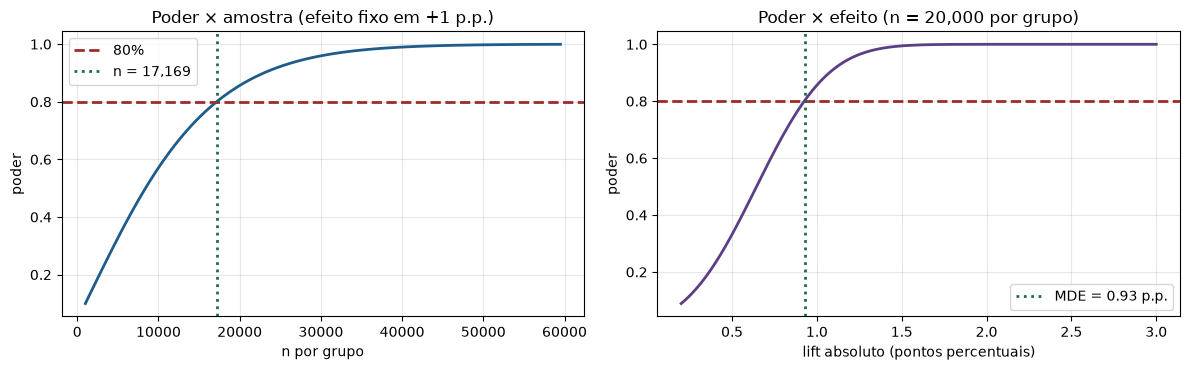

In [10]:
P0, LIFT_ABS, ALFA = 0.12, 0.01, 0.05
P1 = P0 + LIFT_ABS


def n_por_grupo(p0, p1, alfa=0.05, poder=0.80):
    """Tamanho por grupo para comparar duas proporções (teste bilateral)."""
    z_a, z_b = stats.norm.isf(alfa / 2), stats.norm.isf(1 - poder)
    p_barra = (p0 + p1) / 2
    num = (z_a * np.sqrt(2 * p_barra * (1 - p_barra))
           + z_b * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2
    return int(np.ceil(num / (p1 - p0) ** 2))


def poder_de(n, p0, p1, alfa=0.05):
    z_a = stats.norm.isf(alfa / 2)
    ep = np.sqrt(p0 * (1 - p0) / n + p1 * (1 - p1) / n)
    return stats.norm.sf(z_a - abs(p1 - p0) / ep)


n80, n90 = n_por_grupo(P0, P1, poder=0.80), n_por_grupo(P0, P1, poder=0.90)
painel("Dimensionamento do experimento",
       conversao_base=P0, lift_absoluto_alvo=LIFT_ABS,
       n_por_grupo_80pct=float(n80), n_por_grupo_90pct=float(n90),
       total_80pct=float(2 * n80), total_90pct=float(2 * n90))

# MDE com orçamento fixo
ORCAMENTO = 20_000
grade_lift = np.linspace(0.002, 0.03, 400)
poderes = poder_de(ORCAMENTO, P0, P0 + grade_lift)
mde = grade_lift[np.argmax(poderes >= 0.80)]
print(f"Com {ORCAMENTO:,} por grupo, o MDE a 80% de poder é "
      f"{mde:.4f} absoluto ({mde/P0:.1%} relativo).\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
grade_n = np.arange(1000, 60_000, 500)
axes[0].plot(grade_n, poder_de(grade_n, P0, P1), color=AZUL, lw=2)
axes[0].axhline(0.80, color=VERMELHO, ls="--", lw=2, label="80%")
axes[0].axvline(n80, color=VERDE, ls=":", lw=2, label=f"n = {n80:,}")
axes[0].set_xlabel("n por grupo"); axes[0].set_ylabel("poder")
axes[0].set_title("Poder × amostra (efeito fixo em +1 p.p.)"); axes[0].legend()

axes[1].plot(grade_lift * 100, poderes, color=ROXO, lw=2)
axes[1].axhline(0.80, color=VERMELHO, ls="--", lw=2)
axes[1].axvline(mde * 100, color=VERDE, ls=":", lw=2, label=f"MDE = {mde*100:.2f} p.p.")
axes[1].set_xlabel("lift absoluto (pontos percentuais)"); axes[1].set_ylabel("poder")
axes[1].set_title(f"Poder × efeito (n = {ORCAMENTO:,} por grupo)"); axes[1].legend()
plt.tight_layout(); plt.show()

**A conversa que essa conta permite ter com o time de produto:** em vez de
"vamos rodar duas semanas e ver", a pergunta vira "o menor efeito que nos
interessa custa X usuários; temos esse tráfego?". Se a resposta for não, você
**sabe antes** que o experimento não vai concluir nada — e pode escolher entre
testar uma mudança mais ousada, agregar semanas, ou reduzir a variância com
CUPED.

**Análise de poder post-hoc é inútil** — pior, é enganosa. Calcular "poder"
usando o efeito observado depois do experimento é apenas o p-valor
reescrito em outra escala; não adiciona informação nenhuma. Poder se calcula
**antes**, com o efeito que *importaria*, não com o que apareceu.

---
## Exercício 5 🟡 — Comparações múltiplas: como fabricar uma descoberta

1. Simule uma análise de A/B test **sem nenhum efeito real**, mas com 20
   segmentos analisados (idade, região, dispositivo…).
2. Qual a chance de pelo menos um segmento dar $p < 0{,}05$?
3. Aplique Bonferroni e Benjamini-Hochberg (FDR) e compare.

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
M_SEGMENTOS, REPS = 20, 4000


def experimento_sem_efeito(m, n=400):
    return np.array([stats.ttest_ind(rng.normal(0, 1, n), rng.normal(0, 1, n)).pvalue
                     for _ in range(m)])


pelo_menos_um = np.mean([(experimento_sem_efeito(M_SEGMENTOS) < 0.05).any()
                         for _ in range(REPS // 8)])
painel("Analisando 20 segmentos sem NENHUM efeito real",
       FWER_empirico=pelo_menos_um,
       FWER_teorico=1 - 0.95 ** M_SEGMENTOS)

# uma rodada concreta, agora com 3 efeitos reais escondidos entre 20 testes
p_vals = experimento_sem_efeito(17)
p_reais = np.array([stats.ttest_ind(rng.normal(0, 1, 400), rng.normal(0.3, 1, 400)).pvalue
                    for _ in range(3)])
p_todos = np.concatenate([p_vals, p_reais])
verdadeiro_efeito = np.array([False] * 17 + [True] * 3)

ordem = np.argsort(p_todos)
p_ord, real_ord = p_todos[ordem], verdadeiro_efeito[ordem]
m = len(p_ord)

bonf = p_ord < 0.05 / m
limiar_bh = 0.05 * np.arange(1, m + 1) / m
maior_k = np.where(p_ord <= limiar_bh)[0]
bh = np.zeros(m, dtype=bool)
if len(maior_k):
    bh[: maior_k[-1] + 1] = True

print(pd.DataFrame({
    "p": p_ord.round(5), "efeito_real": real_ord,
    "sem_correcao": p_ord < 0.05, "bonferroni": bonf, "BH_fdr": bh,
}).to_string(index=False))

print(f"\nsem correção : {(p_ord < 0.05).sum()} descobertas, "
      f"{((p_ord < 0.05) & ~real_ord).sum()} falsas")
print(f"Bonferroni   : {bonf.sum()} descobertas, {(bonf & ~real_ord).sum()} falsas")
print(f"BH (FDR)     : {bh.sum()} descobertas, {(bh & ~real_ord).sum()} falsas")

Analisando 20 segmentos sem NENHUM efeito real
------------------------------------------------
FWER empirico                           0.63000
FWER teorico                            0.64151

      p  efeito_real  sem_correcao  bonferroni  BH_fdr
0.00000         True          True        True    True
0.00000         True          True        True    True
0.00000         True          True        True    True
0.09746        False         False       False   False
0.23783        False         False       False   False
0.24343        False         False       False   False
0.25240        False         False       False   False
0.28681        False         False       False   False
0.31787        False         False       False   False
0.32945        False         False       False   False
0.35911        False         False       False   False
0.39208        False         False       False   False
0.39553        False         False       False   False
0.50388        False         False   

**O mecanismo:** com 20 testes independentes e $\alpha = 0{,}05$ cada, a chance
de pelo menos um falso positivo é $1 - 0{,}95^{20} \approx 64\%$. Não é má-fé;
é aritmética. Qualquer análise que fatie o resultado por segmento até "achar
onde funcionou" está garantindo esse número.

**Bonferroni × BH — escolha pelo custo do erro:**

- **Bonferroni** controla a chance de **qualquer** falso positivo (FWER). É
  conservador e derruba poder. Use quando um único falso positivo é caro:
  aprovação de fármaco, mudança irreversível de sistema.
- **Benjamini-Hochberg** controla a **proporção esperada de falsos entre as
  descobertas** (FDR). Aceita alguns falsos em troca de muito mais poder. Use
  em triagem exploratória: qual das 500 features investigar, quais segmentos
  merecem um teste confirmatório dedicado.

**A regra operacional:** decida a lista de análises **antes** de ver os dados,
e declare uma métrica primária. Segmentação exploratória é gerador de
hipóteses — nunca conclusão.

---
## Exercício 6 🔴 — Espiar mata: a inflação do erro por peeking

Simule um A/B test **sem efeito** em que o analista checa o p-valor a cada 500
usuários e para assim que $p < 0{,}05$.

1. Qual a taxa real de falsos positivos desse procedimento?
2. Compare com o teste feito uma única vez, no fim.
3. Implemente uma correção de **fronteira sequencial** (limites de O'Brien-
   Fleming aproximados) e mostre que ela restaura o controle.

In [13]:
# --- sua resposta ---

### Gabarito 6

Taxa de falso positivo (não há efeito nenhum)
------------------------------------------------
espiando 10x sem correcao               0.19333
testando so no fim                      0.04750
espiando com OBrien Fleming             0.06500
alfa nominal                            0.05000

fronteiras de O'Brien-Fleming por checagem:
  n =   500  ( 10% da amostra)  rejeita se p < 0.00000
  n =  1000  ( 20% da amostra)  rejeita se p < 0.00001
  n =  1500  ( 30% da amostra)  rejeita se p < 0.00035
  n =  2000  ( 40% da amostra)  rejeita se p < 0.00194
  n =  2500  ( 50% da amostra)  rejeita se p < 0.00557
  n =  3000  ( 60% da amostra)  rejeita se p < 0.01140
  n =  3500  ( 70% da amostra)  rejeita se p < 0.01915
  n =  4000  ( 80% da amostra)  rejeita se p < 0.02843
  n =  4500  ( 90% da amostra)  rejeita se p < 0.03883
  n =  5000  (100% da amostra)  rejeita se p < 0.05000


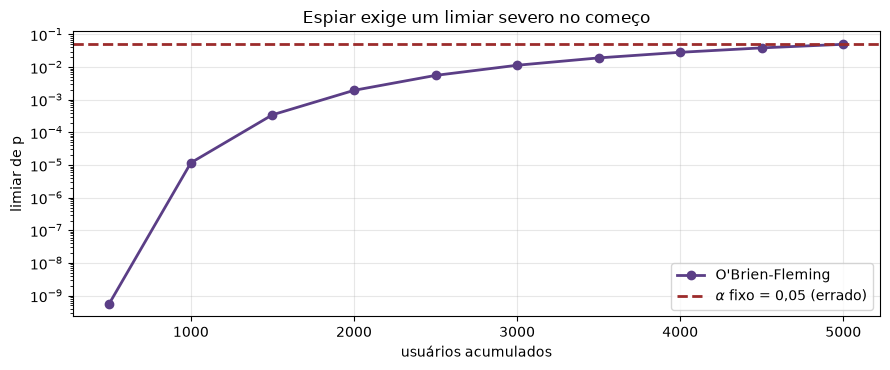

In [14]:
N_FINAL, PASSO, REPS = 5000, 500, 1200
CHECKS = np.arange(PASSO, N_FINAL + 1, PASSO)


def roda_experimento(fronteiras=None):
    """Devolve (parou_e_rejeitou, rejeitou_so_no_fim) para UM experimento sem efeito."""
    a, b = rng.normal(0, 1, N_FINAL), rng.normal(0, 1, N_FINAL)
    parou = False
    for k, ponto in enumerate(CHECKS):
        p = stats.ttest_ind(a[:ponto], b[:ponto]).pvalue
        limite = 0.05 if fronteiras is None else fronteiras[k]
        if p < limite:
            parou = True
            break
    p_final = stats.ttest_ind(a, b).pvalue
    return parou, p_final < 0.05


# O'Brien-Fleming: limiar muito severo cedo, relaxando até ~alfa no fim
fracao = CHECKS / N_FINAL
z_of = stats.norm.isf(0.05 / 2) / np.sqrt(fracao)
fronteiras_of = 2 * stats.norm.sf(z_of)

sem_correcao = np.array([roda_experimento() for _ in range(REPS)])
com_correcao = np.array([roda_experimento(fronteiras_of)[0] for _ in range(REPS)])

painel("Taxa de falso positivo (não há efeito nenhum)",
       espiando_10x_sem_correcao=sem_correcao[:, 0].mean(),
       testando_so_no_fim=sem_correcao[:, 1].mean(),
       espiando_com_OBrien_Fleming=com_correcao.mean(),
       alfa_nominal=0.05)

print("fronteiras de O'Brien-Fleming por checagem:")
for ponto, lim in zip(CHECKS, fronteiras_of):
    print(f"  n = {ponto:>5d}  ({ponto/N_FINAL:>4.0%} da amostra)  rejeita se p < {lim:.5f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(CHECKS, fronteiras_of, "o-", color=ROXO, lw=2, label="O'Brien-Fleming")
ax.axhline(0.05, color=VERMELHO, ls="--", lw=2, label=r"$\alpha$ fixo = 0,05 (errado)")
ax.set_yscale("log"); ax.set_xlabel("usuários acumulados"); ax.set_ylabel("limiar de p")
ax.set_title("Espiar exige um limiar severo no começo")
ax.legend(); plt.tight_layout(); plt.show()

**O resultado:** espiar 10 vezes com $\alpha = 0{,}05$ fixo leva a taxa real de
falso positivo para perto de **20%** — quatro vezes o prometido. E note que
*nada no código do analista está errado*: cada teste individual é impecável. O
que quebrou foi o **procedimento**, não o cálculo.

**Por que a fronteira de O'Brien-Fleming funciona:** ela gasta muito pouco
$\alpha$ nas checagens iniciais (com 10% da amostra, exige $p$ na casa de
$10^{-5}$) e vai relaxando até chegar perto de 0,05 na análise final. O
orçamento total de erro tipo I permanece 5%.

**O que isso significa na prática:** dashboards de A/B test que mostram
"significância" em tempo real são armadilhas se o time tem autoridade para
parar o teste. Ou você fixa a duração de antemão, ou usa testes sequenciais
de verdade (O'Brien-Fleming, alpha spending, ou testes *always-valid*
baseados em razão de verossimilhança).

---
## Exercício 7 🔴 — Desafio: o relatório de teste que um sênior assina

Escreva `reporta_teste(a, b, nome_metrica, alfa=0.05)` que produza um laudo
completo em vez de um p-valor solto:

1. escolha automática entre Welch e Mann-Whitney (por assimetria/normalidade);
2. tamanho de efeito (d de Cohen **e** diferença bruta com IC bootstrap);
3. o p-valor, com a interpretação correta em texto;
4. avisos: n pequeno, poder baixo, efeito significativo mas irrelevante.

In [15]:
# --- sua resposta ---

### Gabarito 7

In [16]:
def reporta_teste(a, b, nome_metrica="métrica", alfa=0.05, efeito_minimo_relevante=None,
                  B=4000, semente=1):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n_a, n_b = len(a), len(b)
    gerador = np.random.default_rng(semente)

    assimetria = max(abs(stats.skew(a)), abs(stats.skew(b)))
    usa_nao_parametrico = assimetria > 1.0
    if usa_nao_parametrico:
        teste, resultado = "Mann-Whitney U", stats.mannwhitneyu(a, b, alternative="two-sided")
    else:
        teste, resultado = "t de Welch", stats.ttest_ind(a, b, equal_var=False)

    dif = b.mean() - a.mean()
    dp_agrupado = np.sqrt(((n_a - 1) * a.var(ddof=1) + (n_b - 1) * b.var(ddof=1))
                          / (n_a + n_b - 2))
    d_cohen = dif / dp_agrupado

    boot = np.array([gerador.choice(b, n_b, replace=True).mean()
                     - gerador.choice(a, n_a, replace=True).mean() for _ in range(B)])
    ic = np.percentile(boot, [100 * alfa / 2, 100 * (1 - alfa / 2)])

    n_harm = 2 / (1 / n_a + 1 / n_b)
    poder = stats.norm.sf(stats.norm.isf(alfa / 2) - abs(d_cohen) * np.sqrt(n_harm / 2))

    print(f"=== {nome_metrica} ===")
    print(f"controle    n = {n_a:>6d}   média = {a.mean():>10.4f}   mediana = {np.median(a):>10.4f}")
    print(f"tratamento  n = {n_b:>6d}   média = {b.mean():>10.4f}   mediana = {np.median(b):>10.4f}")
    print(f"\nteste aplicado: {teste}  (assimetria máx = {assimetria:.2f})")
    print(f"p-valor: {resultado.pvalue:.6f}")
    print(f"  → se não houvesse diferença alguma, dados tão extremos quanto estes")
    print(f"    apareceriam em {resultado.pvalue:.2%} das repetições do experimento.")
    print(f"\ndiferença bruta: {dif:+.4f}  ({dif/abs(a.mean()):+.2%} relativo)")
    print(f"IC {1-alfa:.0%} da diferença: [{ic[0]:+.4f}, {ic[1]:+.4f}]")
    print(f"d de Cohen: {d_cohen:+.3f}   poder aproximado: {poder:.1%}")

    avisos = []
    if min(n_a, n_b) < 30:
        avisos.append(f"n pequeno (mín {min(n_a, n_b)}) — resultado instável")
    if poder < 0.80 and resultado.pvalue >= alfa:
        avisos.append(f"poder de apenas {poder:.0%}: 'não significativo' aqui NÃO é "
                      "evidência de ausência de efeito")
    if resultado.pvalue < alfa and abs(d_cohen) < 0.1:
        avisos.append("significativo mas com efeito desprezível (|d| < 0,1) — "
                      "sintoma clássico de n grande demais para a pergunta")
    if efeito_minimo_relevante is not None and ic[0] < efeito_minimo_relevante < ic[1]:
        avisos.append(f"o IC contém o efeito mínimo relevante ({efeito_minimo_relevante}): "
                      "o experimento não separa 'irrelevante' de 'vale a pena'")
    if (ic[0] < 0 < ic[1]) and resultado.pvalue < alfa:
        avisos.append("IC bootstrap cruza zero mas o p-valor rejeita — investigue "
                      "a discrepância antes de reportar")

    print("\nAVISOS" if avisos else "\nsem avisos")
    for w in avisos:
        print(f"  ! {w}")
    print()
    return {"teste": teste, "p": resultado.pvalue, "d": d_cohen, "ic": ic, "poder": poder}


print(">>> caso 1: efeito real e amostra adequada")
_ = reporta_teste(rng.normal(100, 15, 900), rng.normal(104, 15, 900),
                  "ticket médio (R$)", efeito_minimo_relevante=2.0)

print(">>> caso 2: n gigante, efeito irrisório")
_ = reporta_teste(rng.normal(100, 15, 90_000), rng.normal(100.2, 15, 90_000),
                  "tempo na página (s)")

print(">>> caso 3: subdimensionado")
_ = reporta_teste(rng.normal(100, 15, 20), rng.normal(107, 15, 20),
                  "NPS piloto")

print(">>> caso 4: métrica assimétrica")
_ = reporta_teste(rng.lognormal(np.log(120), 0.7, 500),
                  rng.lognormal(np.log(132), 0.7, 500), "latência (ms)")

>>> caso 1: efeito real e amostra adequada
=== ticket médio (R$) ===
controle    n =    900   média =    99.3516   mediana =    99.1239
tratamento  n =    900   média =   103.5267   mediana =   103.1934

teste aplicado: t de Welch  (assimetria máx = 0.05)
p-valor: 0.000000
  → se não houvesse diferença alguma, dados tão extremos quanto estes
    apareceriam em 0.00% das repetições do experimento.

diferença bruta: +4.1750  (+4.20% relativo)
IC 95% da diferença: [+2.8103, +5.5272]
d de Cohen: +0.279   poder aproximado: 100.0%

sem avisos

>>> caso 2: n gigante, efeito irrisório


=== tempo na página (s) ===
controle    n =  90000   média =   100.0139   mediana =   100.0270
tratamento  n =  90000   média =   100.1862   mediana =   100.1491

teste aplicado: t de Welch  (assimetria máx = 0.02)
p-valor: 0.014989
  → se não houvesse diferença alguma, dados tão extremos quanto estes
    apareceriam em 1.50% das repetições do experimento.

diferença bruta: +0.1723  (+0.17% relativo)
IC 95% da diferença: [+0.0336, +0.3100]
d de Cohen: +0.011   poder aproximado: 68.2%

AVISOS
  ! significativo mas com efeito desprezível (|d| < 0,1) — sintoma clássico de n grande demais para a pergunta

>>> caso 3: subdimensionado
=== NPS piloto ===
controle    n =     20   média =    98.3021   mediana =    99.0300
tratamento  n =     20   média =   103.1972   mediana =    99.4909

teste aplicado: t de Welch  (assimetria máx = 0.34)
p-valor: 0.271975
  → se não houvesse diferença alguma, dados tão extremos quanto estes
    apareceriam em 27.20% das repetições do experimento.

diferença b

**O que separa esse relatório de um `print(p)`:**

- **O caso 2** é o erro mais comum de empresa com muito tráfego: $p < 10^{-6}$
  com $d = 0{,}01$. O teste está certo e a decisão de negócio seria errada. O
  aviso automático existe para que ninguém precise lembrar de olhar.
- **O caso 3** produz "não significativo" com poder de ~30%. Sem o aviso, esse
  resultado vira "a mudança não funciona" na reunião seguinte — e a hipótese
  morre por falta de amostra, não por falta de efeito.
- **O IC da diferença bruta** é o que o time de produto consegue usar: "entre
  +R$ 1,80 e +R$ 6,20 por pedido" responde a pergunta de investimento; "p =
  0,003" não responde nada.

Automatizar o julgamento é o ponto. Toda armadilha deste módulo é conhecida —
o que falha é lembrar de checar cada uma, toda vez, sob prazo.

---
## Fechamento

- **p-valor é $P(\text{dados} \mid H_0)$**, nunca o contrário.
- **Sob $H_0$ o p-valor é uniforme** — e todo pecado metodológico (espiar,
  fatiar, escolher o teste depois) destrói essa uniformidade.
- **Poder se calcula antes.** Post-hoc não informa nada.
- **Nunca reporte significância sem tamanho de efeito e intervalo.**
- **20 segmentos sem correção ⇒ 64% de chance de uma descoberta falsa.**
- **Welch por padrão; pareado quando houver pareamento.**

→ Próximo módulo: **Estatística Bayesiana** — onde "95% de chance de o efeito
estar aqui" finalmente passa a ser uma frase legítima.